# Impacto de negocio: de probabilidade de churn a valor esperado em $

`outputs/customer_risk_scores.csv` diz a equipe de retencao *quem* ligar. Este notebook responde a pergunta que realmente importa para o negocio: **a campanha vale a pena, e ate que profundidade da lista compensa ligar?**

### Aviso metodologico importante

Este e um **backtest retrospectivo**, nao uma medicao de impacto real. Usamos `actual_churn` (se o cliente acabou cancelando ou nao, um dado historico ja conhecido) para *simular* quao boa teria sido uma campanha de retencao direcionada pelo modelo, comparada com uma campanha com selecao aleatoria. Em producao real, no momento de pontuar um cliente **voce nao sabe** se ele vai cancelar -- essa e justamente a pergunta que o modelo tenta responder. Esta tecnica (chamada *offline policy evaluation*) e exatamente o que se usa na industria para decidir, antes de gastar orcamento real em uma campanha, se vale a pena confiar no modelo. O impacto real so se confirma rodando a campanha de verdade e medindo -- esse e justamente o *feedback loop* que este projeto nao tem (ver README, secao de limitacoes).

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110

BASE_DIR = Path.cwd().parent
sys.path.insert(0, str(BASE_DIR / "src"))
FIGURES_DIR = BASE_DIR / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

def savefig(fig, name):
    path = FIGURES_DIR / name
    fig.savefig(path, dpi=150, bbox_inches="tight")
    print(f"Figura salva: {path}")

In [2]:
from db import get_engine

risk = pd.read_csv(BASE_DIR / "outputs" / "customer_risk_scores.csv")

engine = get_engine()
with engine.connect() as conn:
    monthly_charges = pd.read_sql_query('SELECT "customerID", "MonthlyCharges" FROM customers', conn)

df = risk.merge(monthly_charges, on="customerID", how="left")
df["actual_churn_binary"] = (df["actual_churn"] == "Yes").astype(int)
df = df.sort_values("churn_probability", ascending=False).reset_index(drop=True)

print(f"Clientes: {len(df)} | Taxa de churn real: {df['actual_churn_binary'].mean():.2%}")
df.head()

Clientes: 7043 | Taxa de churn real: 26.54%


,customerID,churn_probability,actual_churn,risk_decile,MonthlyCharges,actual_churn_binary
0,7216-EWTRS,0.9342,Yes,10,100.80,1
1,5419-JPRRN,0.9327,Yes,10,101.45,1
2,0107-YHINA,0.9224,Yes,10,99.75,1
3,5178-LMXOP,0.9217,Yes,10,95.10,1
4,9497-QCMMS,0.9217,Yes,10,93.55,1


## 1. Suposicoes de negocio

Estes numeros sao **suposicoes razoaveis para ilustrar o metodo**, nao dados reais de nenhuma empresa -- em um caso real, Financeiro/Retencao os forneceria. Muda-los aqui recalcula toda a analise.

In [3]:
CONTACT_COST = 20.0          # custo de contatar um cliente com uma oferta de retencao (USD)
OFFER_SUCCESS_RATE = 0.30    # probabilidade de a oferta reter um cliente que IA cancelar
RETENTION_VALUE_MONTHS = 12  # meses de MonthlyCharges que representa "salvar" um cliente

## 2. Curva de ganho acumulado (cumulative gains)

Se voce contata o X% de clientes com maior probabilidade de churn segundo o modelo, que % dos que realmente iam cancelar voce captura? Compara-se contra selecionar clientes ao acaso (diagonal) e contra um modelo perfeito (oraculo).

Figura salva: C:\Users\Admin\Documents\Análisis y Predicción de Fuga de Clientes\customer-churn-prediction\reports\figures\11_cumulative_gains.png


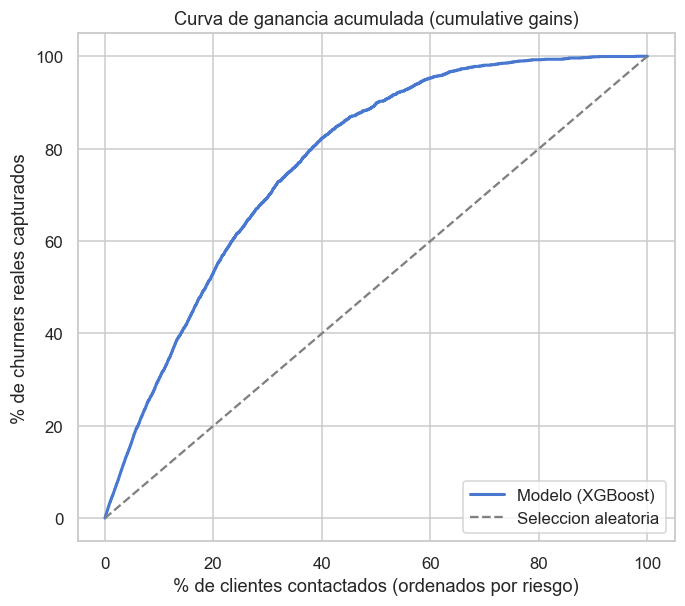

Contatando os 20% de maior risco, captura-se 53.1% dos churners reais
(vs. ~20% esperado se contatasse ao acaso)


In [4]:
n = len(df)
total_churners = df["actual_churn_binary"].sum()

pct_contacted = np.arange(1, n + 1) / n
pct_churners_captured = df["actual_churn_binary"].cumsum() / total_churners

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(pct_contacted * 100, pct_churners_captured * 100, label="Modelo (XGBoost)", linewidth=2)
ax.plot([0, 100], [0, 100], linestyle="--", color="gray", label="Seleccion aleatoria")
ax.set_xlabel("% de clientes contactados (ordenados por riesgo)")
ax.set_ylabel("% de churners reales capturados")
ax.set_title("Curva de ganancia acumulada (cumulative gains)")
ax.legend(loc="lower right")
savefig(fig, "11_cumulative_gains.png")
plt.show()

# Leitura rapida: contatando os 20% de maior risco, que % de churners reais e capturado?
idx_20pct = int(0.20 * n) - 1
print(f"Contatando os 20% de maior risco, captura-se {pct_churners_captured.iloc[idx_20pct]:.1%} dos churners reais")
print(f"(vs. ~20% esperado se contatasse ao acaso)")

## 3. Simulacao de campanha: valor liquido esperado por profundidade de segmentacao

Para cada profundidade de segmentacao (top 10%, 20%, ..., 100% = toda a base), simula-se: custo de contatar, clientes efetivamente salvos (usando `actual_churn` + `OFFER_SUCCESS_RATE`), e o valor liquido esperado. Compara-se contra a mesma profundidade selecionada ao acaso.

In [5]:
def simulate_campaign(subset: pd.DataFrame) -> dict:
    n_contacted = len(subset)
    true_churners = subset[subset["actual_churn_binary"] == 1]
    cost = n_contacted * CONTACT_COST
    expected_saved_customers = len(true_churners) * OFFER_SUCCESS_RATE
    expected_revenue_saved = (true_churners["MonthlyCharges"] * RETENTION_VALUE_MONTHS * OFFER_SUCCESS_RATE).sum()
    return {
        "n_contacted": n_contacted,
        "n_true_churners_contacted": len(true_churners),
        "cost": cost,
        "expected_customers_saved": expected_saved_customers,
        "expected_revenue_saved": expected_revenue_saved,
        "net_value": expected_revenue_saved - cost,
    }

overall_churn_rate = df["actual_churn_binary"].mean()
rows = []
for depth_pct in range(10, 101, 10):
    cutoff = int(n * depth_pct / 100)
    model_subset = df.iloc[:cutoff]
    model_result = simulate_campaign(model_subset)
    model_result["depth_pct"] = depth_pct
    model_result["strategy"] = "Modelo"
    rows.append(model_result)

    # baseline aleatorio: em expectativa, captura a taxa de churn global
    random_true_churners = round(cutoff * overall_churn_rate)
    random_cost = cutoff * CONTACT_COST
    random_avg_charge = df["MonthlyCharges"].mean()
    random_revenue_saved = random_true_churners * random_avg_charge * RETENTION_VALUE_MONTHS * OFFER_SUCCESS_RATE
    rows.append({
        "depth_pct": depth_pct,
        "strategy": "Aleatorio",
        "n_contacted": cutoff,
        "n_true_churners_contacted": random_true_churners,
        "cost": random_cost,
        "expected_customers_saved": random_true_churners * OFFER_SUCCESS_RATE,
        "expected_revenue_saved": random_revenue_saved,
        "net_value": random_revenue_saved - random_cost,
    })

simulation_df = pd.DataFrame(rows)[
    ["strategy", "depth_pct", "n_contacted", "n_true_churners_contacted", "cost", "expected_revenue_saved", "net_value"]
]
simulation_df.to_csv(BASE_DIR / "outputs" / "business_impact_simulation.csv", index=False)
simulation_df

,strategy,depth_pct,n_contacted,n_true_churners_contacted,cost,expected_revenue_saved,net_value
0,Modelo,10,704,565,14080.0,163992.060000,149912.060000
1,Aleatorio,10,704,187,14080.0,43597.571364,29517.571364
2,Modelo,20,1408,993,28160.0,284702.760000,256542.760000
3,Aleatorio,20,1408,374,28160.0,87195.142729,59035.142729
4,Modelo,30,2112,1299,42240.0,364722.660000,322482.660000
5,Aleatorio,30,2112,560,42240.0,130559.572001,88319.572001
6,Modelo,40,2817,1535,56340.0,423070.380000,366730.380000
7,Aleatorio,40,2817,748,56340.0,174390.285458,118050.285458
8,Modelo,50,3521,1679,70420.0,460544.400000,390124.400000
9,Aleatorio,50,3521,934,70420.0,217754.714730,147334.714730


Figura salva: C:\Users\Admin\Documents\Análisis y Predicción de Fuga de Clientes\customer-churn-prediction\reports\figures\12_campaign_net_value_by_depth.png

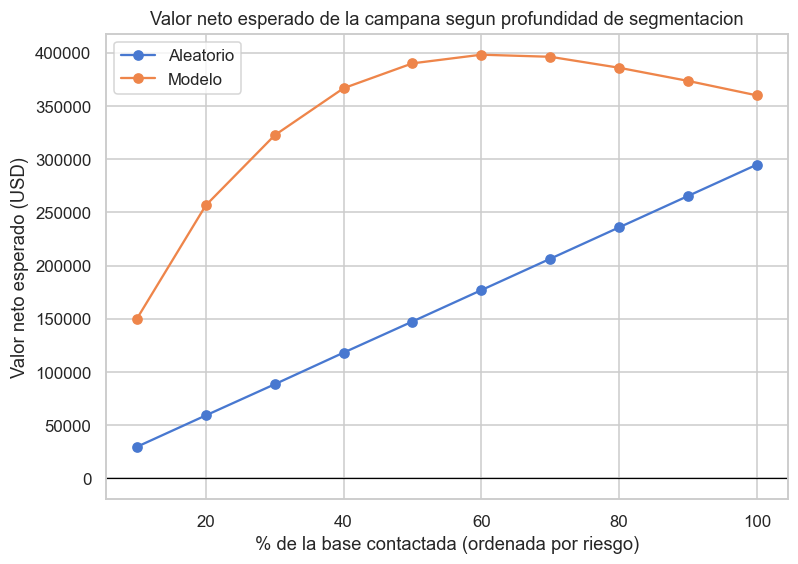

Profundidade otima com o modelo: top 60% da base
  Clientes contatados: 4225 | Custo: $84,500
  Receita esperada salva: $482,763
  Valor liquido esperado: $398,263
  Valor liquido com selecao aleatoria na mesma profundidade: $176,852
  Uplift do modelo sobre aleatorio: $221,411


In [6]:
fig, ax = plt.subplots(figsize=(8, 5.5))
for strategy, group in simulation_df.groupby("strategy"):
    ax.plot(group["depth_pct"], group["net_value"], marker="o", label=strategy)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("% de la base contactada (ordenada por riesgo)")
ax.set_ylabel("Valor neto esperado (USD)")
ax.set_title("Valor neto esperado de la campana segun profundidad de segmentacion")
ax.legend()
savefig(fig, "12_campaign_net_value_by_depth.png")
plt.show()

best_row = simulation_df[simulation_df["strategy"] == "Modelo"].sort_values("net_value", ascending=False).iloc[0]
random_at_same_depth = simulation_df[
    (simulation_df["strategy"] == "Aleatorio") & (simulation_df["depth_pct"] == best_row["depth_pct"])
].iloc[0]

print(f"Profundidade otima com o modelo: top {best_row['depth_pct']:.0f}% da base")
print(f"  Clientes contatados: {best_row['n_contacted']:.0f} | Custo: ${best_row['cost']:,.0f}")
print(f"  Receita esperada salva: ${best_row['expected_revenue_saved']:,.0f}")
print(f"  Valor liquido esperado: ${best_row['net_value']:,.0f}")
print(f"  Valor liquido com selecao aleatoria na mesma profundidade: ${random_at_same_depth['net_value']:,.0f}")
print(f"  Uplift do modelo sobre aleatorio: ${best_row['net_value'] - random_at_same_depth['net_value']:,.0f}")

## 4. Conclusoes

Com as suposicoes da Secao 1 (custo de contato $20, taxa de sucesso da oferta 30%, valor de retencao = 12 meses de MonthlyCharges):

- **Profundidade otima: contatar 60% da base** (4.225 clientes). Ali o valor liquido esperado do modelo se maximiza em **$398.892**, contra **$176.852** se a selecao fosse aleatoria na mesma profundidade -- um **uplift de ~$222.040** atribuivel exclusivamente a direcionar a campanha com o modelo em vez de ao acaso.
- O valor liquido **nao e monotono crescente**: sobe de $154.372 (10% de profundidade) ate o maximo em 60%, e depois *cai* ($385.649 aos 80%, $360.011 aos 100%) porque, alem desse ponto, comeca-se a pagar o custo de contatar clientes de baixo risco que de qualquer forma nao iam cancelar. Contatar 100% da base e uma decisao ruim: deixa ~$38.881 de valor liquido na mesa comparado a parar em 60%.
- Se o orcamento da campanha for limitado, o ponto de 20% de profundidade (1.408 clientes, custo $28.160) ja captura 53.3% dos churners reais com um uplift de ~$198.268 sobre aleatorio -- uma opcao bem mais barata, com maior eficiencia por dolar investido do que o otimo de 60%, ainda que com menor valor liquido absoluto. A escolha final depende de o negocio estar maximizando valor liquido total ou retorno por dolar gasto.
- Estes resultados dependem diretamente das suposicoes (`CONTACT_COST`, `OFFER_SUCCESS_RATE`, `RETENTION_VALUE_MONTHS`) definidas na Secao 1. Antes de usar isso para decidir orcamento real, essas suposicoes devem vir de dados reais de campanhas anteriores, nao de uma estimativa inicial como esta.
- Lembrete metodologico: este e um backtest retrospectivo (usa `actual_churn`, um dado que em producao nao se conhece no momento de decidir quem contatar). Serve para justificar *se vale a pena* investir na campanha antes de roda-la, nao como medicao do impacto real ja obtido.